In [1]:
import pandas as pd
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mlflow.get_tracking_uri()

'sqlite:///C:/data-science-projects/major-projects/youtube_comment_analysis/notebooks/mlflow.db'

In [3]:
mlflow.set_tracking_uri("http://localhost:5000")      # local MLflow server
mlflow.set_experiment("Baseline model - 2")           # experiment name

2026/04/14 11:15:29 INFO mlflow.tracking.fluent: Experiment with name 'Baseline model - 2' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/11', creation_time=1776145529657, experiment_id='11', last_update_time=1776145529657, lifecycle_stage='active', name='Baseline model - 2', tags={}, workspace='default'>

In [4]:
data = pd.read_csv(r'../data/processed/dataset.csv')

In [5]:
data = data.dropna(subset=['text_processed', 'sentiment'])

In [6]:
data.shape

(10036, 5)

In [7]:
data = data.drop_duplicates()

In [8]:
data.shape

(9969, 5)

##### Split

In [9]:
X_text = data['text_processed']
X_numeric = data[['char_count', 'word_count', 'avg_word_len']].values
y = data['sentiment']


In [10]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
X_text_train.shape

(7975,)

##### feature_representation

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_text_train = tfidf.fit_transform(X_text_train)
X_text_test  = tfidf.transform(X_text_test)

In [13]:
X_text_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 96082 stored elements and shape (7975, 5000)>

##### Scaling

In [14]:
# Scale numeric — fit on train only
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)  # fit + transform
X_num_test  = scaler.transform(X_num_test)        # only transform

In [15]:
from scipy.sparse import hstack

# Combine TF-IDF + custom features
X_train_final = hstack([X_text_train, X_num_train])
X_test_final  = hstack([X_text_test,  X_num_test])

              precision    recall  f1-score   support

          -1       0.94      0.89      0.91      1029
           0       0.79      0.91      0.85       455
           1       0.90      0.87      0.88       510

    accuracy                           0.89      1994
   macro avg       0.88      0.89      0.88      1994
weighted avg       0.89      0.89      0.89      1994



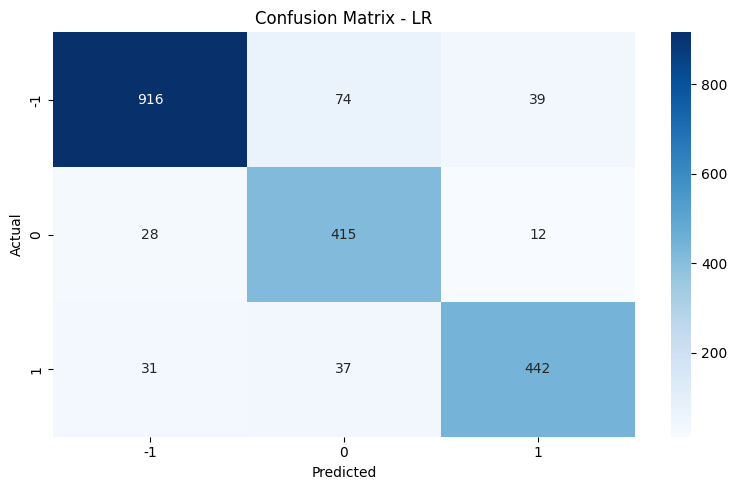

2026/04/14 11:15:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 11:15:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'sentiment-lr-baseline' already exists. Creating a new version of this model...
2026/04/14 11:15:47 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sentiment-lr-baseline, version 7
Created version '7' of model 'sentiment-lr-baseline'.


Run ID: da1912d04d24409db74bccaab6e66b00
🏃 View run baseline-logistic-regression at: http://localhost:5000/#/experiments/11/runs/da1912d04d24409db74bccaab6e66b00
🧪 View experiment at: http://localhost:5000/#/experiments/11


In [16]:
# type: ignore
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)

# ── Run ───────────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name="baseline-logistic-regression"):

    # ── Tags (metadata about the run) ─────────────────────────────────────────
    mlflow.set_tags({
        "author"      : "Rahul Namilakonda",
        "dataset"     : "twitter-reddit-sentiment",
        "model_type"  : "baseline",
        "stage"         : "improved",
        "features"      : "tfidf + char_count + word_count + avg_word_len",                 # baseline / improved / final
    })

    # ── Log Parameters ────────────────────────────────────────────────────────
    mlflow.log_params({
               # Split
        "test_size"             : 0.2,
        "stratify"              : True,
        "random_state"          : 42,

        # TF-IDF
        "tfidf_max_features"    : 5000,
        "tfidf_norm"            : "l2",

        # Scaling
        "scaler"                : "StandardScaler",
        "scaled_features"       : "char_count, word_count, avg_word_len",

        

        # Model
        "model"                 : "LogisticRegression",
        "max_iter"              : 1000,
        "solver"                : "lbfgs",
        "random_state"          : 42,
        "class_weight"          : "balanced",

        # Features
        "num_custom_features"   : 3,
        "tfidf_features"        : 5000,


    })

    # ── Train ─────────────────────────────────────────────────────────────────
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    # ── Log Metrics ───────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "accuracy"         : accuracy_score(y_test, y_pred),
        "f1_weighted"      : f1_score(y_test, y_pred, average='weighted'),
        "f1_macro"         : f1_score(y_test, y_pred, average='macro'),
        "precision_weighted": precision_score(y_test, y_pred, average='weighted'),
        "precision_macro": precision_score(y_test, y_pred, average='macro'),
        "recall_weighted"  : recall_score(y_test, y_pred, average='weighted'),
        "recall_macro"  : recall_score(y_test, y_pred, average='macro'),
    })

    # ── Log Classification Report as artifact ─────────────────────────────────
    report = classification_report(y_test, y_pred)
    print(report)
    with open("../reports/model/classification_report_baseline.txt", "w") as f:
        f.write(report)
    mlflow.log_artifact("../reports/model/classification_report_baseline.txt")

    # ── Log Confusion Matrix as artifact ──────────────────────────────────────
    plt.figure(figsize=(8, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Confusion Matrix - LR')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig("../reports/model/confusion_matrix_baseline.png")
    mlflow.log_artifact("../reports/model/confusion_matrix_baseline.png")
    plt.show()

    # ── Log Model ─────────────────────────────────────────────────────────────
    mlflow.sklearn.log_model(model, artifact_path="model",
                             registered_model_name="sentiment-lr-baseline")

    print(f"Run ID: {mlflow.active_run().info.run_id}")